# 🧹 StartupCoach — Data Preprocessing Pipeline

Project: StartupCoach — LLM-Based AI Startup Coach  
Course: Final Project in Computer Science  
Dataset: [Startup Investments (Crunchbase) — Kaggle](https://www.kaggle.com/datasets/arindam235/startup-investments-crunchbase)

---

This notebook performs preprocessing and feature preparation on the Crunchbase startup dataset for startup success classification.

**Pipeline:**
- Load raw Crunchbase data
- Filter companies with unambiguous outcomes
- Handle missing values
- Clean and transform numerical features
- Apply logarithmic transformation to skewed funding variables
- Remove sparse and redundant features
- Clean categorical/object-based features
- Perform correlation analysis
- Export cleaned dataset for ML training

Output:
- `cleaned_crunchbase.csv`

---

## Label Definition

Only companies with unambiguous outcomes were retained:
- acquired → success (1)
- closed → failure (0)

Companies marked as `operating` were removed because their final outcome is unknown.

**Why remove `operating` companies?**  
> A company marked as operating at the time of data collection may later fail or be acquired. Including such companies would introduce label uncertainty and reduce model reliability.

## Step 1: Imports and Definitions

In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Utilities
import warnings

warnings.filterwarnings("ignore")

# Notebook display settings
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 10

pd.set_option("display.max_columns", None)

In [2]:
def display_missing_values(dataframe, title):
    print(f'=== {title} ===')
    missing = dataframe.isnull().sum()
    missing_pct = (missing / len(dataframe) * 100).round(1)
    missing_df = pd.DataFrame({'Missing': missing, 'Pct (%)': missing_pct})
    print(missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False).to_string())

### Refactored Missing Value Summary Function

I've created a helper function `display_missing_values` to standardize how we view missing data. This will be used in subsequent steps.


---
## Step 2 — Load Dataset

Dataset source:
https://www.kaggle.com/datasets/arindam235/startup-investments-crunchbase

In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [4]:
import os
FOLDER_NAME = 'startupcoach'
GOOGLE_DRIVE_PATH = os.path.join('/content/drive/MyDrive', FOLDER_NAME)
print(os.listdir(GOOGLE_DRIVE_PATH))

['crunchbase_raw.csv']


In [5]:
# Load Data
DATA_FILE = 'crunchbase_raw.csv'
df_raw = pd.read_csv(os.path.join(GOOGLE_DRIVE_PATH, DATA_FILE), low_memory=False, encoding='latin-1')
print(f"Dataset loaded successfully: {df_raw.shape}")

Dataset loaded successfully: (54294, 39)


---
## Step 3: Initial Dataset Exploration

We begin by examining the raw dataset structure, feature types, and missing values before applying any preprocessing steps.

In [6]:
# Preview first 5 rows
df_raw.head()

,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,/organization/waywire,#waywire,http://www.waywire.com,|Entertainment|Politics|Social Media|News|,News,"17,50,000",acquired,USA,NY,New York City,New York,1.0,2012-06-01,2012-06,2012-Q2,2012.0,2012-06-30,2012-06-30,1750000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,/organization/tv-communications,&TV Communications,http://enjoyandtv.com,|Games|,Games,"40,00,000",operating,USA,CA,Los Angeles,Los Angeles,2.0,NaN,NaN,NaN,NaN,2010-06-04,2010-09-23,0.0,4000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,/organization/rock-your-paper,'Rock' Your Paper,http://www.rockyourpaper.org,|Publishing|Education|,Publishing,"40,000",operating,EST,NaN,Tallinn,Tallinn,1.0,2012-10-26,2012-10,2012-Q4,2012.0,2012-08-09,2012-08-09,40000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,/organization/in-touch-network,(In)Touch Network,http://www.InTouchNetwork.com,|Electronics|Guides|Coffee|Restaurants|Music|i...,Electronics,"15,00,000",operating,GBR,NaN,London,London,1.0,2011-04-01,2011-04,2011-Q2,2011.0,2011-04-01,2011-04-01,1500000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,/organization/r-ranch-and-mine,-R- Ranch and Mine,NaN,|Tourism|Entertainment|Games|,Tourism,"60,000",operating,USA,TX,Dallas,Fort Worth,2.0,2014-01-01,2014-01,2014-Q1,2014.0,2014-08-17,2014-09-26,0.0,0.0,60000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   permalink             49438 non-null  object 
 1   name                  49437 non-null  object 
 2   homepage_url          45989 non-null  object 
 3   category_list         45477 non-null  object 
 4    market               45470 non-null  object 
 5    funding_total_usd    49438 non-null  object 
 6   status                48124 non-null  object 
 7   country_code          44165 non-null  object 
 8   state_code            30161 non-null  object 
 9   region                44165 non-null  object 
 10  city                  43322 non-null  object 
 11  funding_rounds        49438 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

Initial inspection shows that the dataset contains a mix of numeric and categorical features, along with several columns containing missing values.  
Some features also require preprocessing, such as converting funding amounts and handling date-related columns.

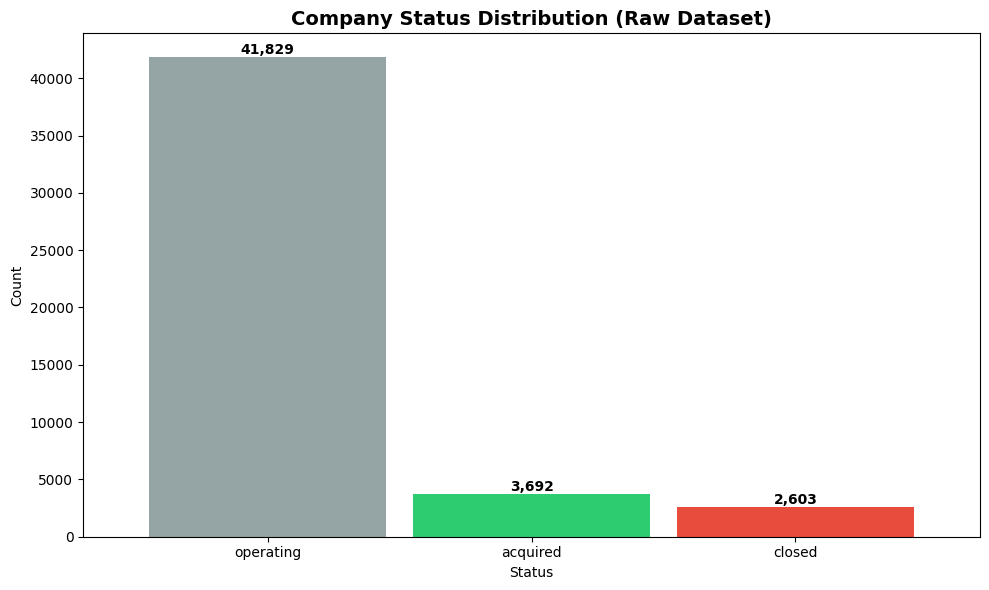

In [8]:
# Status distribution
status_counts = df_raw['status'].dropna().value_counts()

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
status_counts.plot(
    kind='bar',
    ax=ax,
    color=['#95a5a6', '#2ecc71', '#e74c3c'],
    width=0.9
)
ax.set_title(
    'Company Status Distribution (Raw Dataset)',
    fontsize=14,
    fontweight='bold'
)
ax.set_xlabel('Status')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)

# Add labels above bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

The dataset is heavily dominated by companies labeled as `operating`, whose final business outcome is unknown.

To build a reliable binary classification model, only companies with clear outcomes (`acquired` or `closed`) will be retained for model training.

In [9]:
display_missing_values(df_raw, 'Missing Values in Raw Data')

=== Missing Values in Raw Data ===
                      Missing  Pct (%)
state_code              24133     44.4
founded_quarter         15812     29.1
founded_month           15812     29.1
founded_year            15812     29.1
founded_at              15740     29.0
city                    10972     20.2
region                  10129     18.7
country_code            10129     18.7
 market                  8824     16.3
category_list            8817     16.2
homepage_url             8305     15.3
status                   6170     11.4
name                     4857      8.9
 funding_total_usd       4856      8.9
permalink                4856      8.9
funding_rounds           4856      8.9
first_funding_at         4856      8.9
last_funding_at          4856      8.9
seed                     4856      8.9
venture                  4856      8.9
equity_crowdfunding      4856      8.9
undisclosed              4856      8.9
convertible_note         4856      8.9
debt_financing           4856

### Key Observations

- Several columns contain substantial missing values, particularly `state_code` and the `founded_*` date features.
- Geographic features such as `city`, `region`, and `country_code` also contain incomplete data and will require further evaluation during preprocessing.
- Many financial columns share the same missing-value pattern, suggesting that some companies lack funding information entirely.

---
## Step 4: Create Clean Binary Dataset

We apply clean binary outcomes:
- ✅ `acquired` → kept as **success (1)**
- ✅ `closed` → kept as **failure (0)**
- ❌ `operating`, NaN → **dropped**

This gives us ~6,295 rows with unambiguous labels — a clean foundation for the model.

In [10]:
SUCCESS_STATUSES = {'acquired'}
FAILURE_STATUSES = {'closed'}

df = df_raw.copy()
df['status'] = df['status'].str.lower().str.strip() # Normalize status values

mask = df['status'].isin(SUCCESS_STATUSES | FAILURE_STATUSES)
df = df[mask].copy()

# Create binary target
df['success'] = df['status'].map({
    'acquired': 1,
    'closed': 0
})

print(f'Companies remaining: {len(df):,}')
print(f'acquired: {(df["status"] == "acquired").sum():,}')
print(f'closed: {(df["status"] == "closed").sum():,}')

Companies remaining: 6,295
acquired: 3,692
closed: 2,603


The filtered dataset remains moderately imbalanced between success and failure outcomes. This will be addressed later during preprocessing.

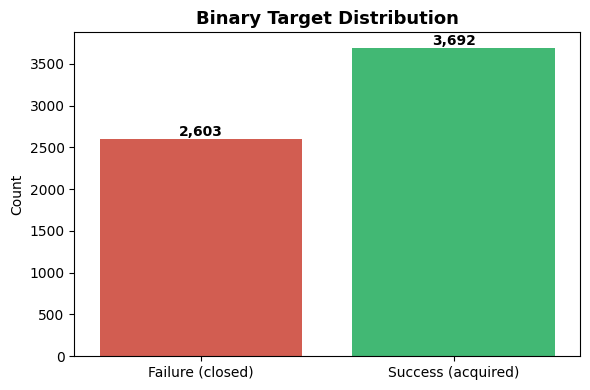

In [11]:
# Class distribution before balancing
fig, ax = plt.subplots(figsize=(6, 4))

sns.countplot(x='success', data=df,  palette=['#e74c3c', '#2ecc71'], ax=ax)
ax.set_xticklabels(['Failure (closed)', 'Success (acquired)']) # Custom labels

# Titles
ax.set_title('Binary Target Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Count')

# Add values above bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

---
## Step 5: Numeric Feature Analysis
We now examine the numerical features in the filtered dataset to better understand their distributions, missing values, and potential outliers before applying preprocessing steps.

In [12]:
cols = df.columns

half = len(cols) // 2

display(df.iloc[:, :half].describe())
display(df.iloc[:, half:].describe())

,funding_rounds,founded_year,seed,venture
count,6295.000000,4967.000000,6.295000e+03,6.295000e+03
mean,1.774106,2005.195692,1.631236e+05,1.028132e+07
std,1.270575,6.433335,7.585670e+05,2.462916e+07
min,1.000000,1911.000000,0.000000e+00,0.000000e+00
25%,1.000000,2003.000000,0.000000e+00,0.000000e+00
50%,1.000000,2007.000000,0.000000e+00,1.507400e+06
75%,2.000000,2009.000000,0.000000e+00,1.100000e+07
max,15.000000,2014.000000,2.500000e+07,7.750000e+08


,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H,success
count,6.295000e+03,6.295000e+03,6.295000e+03,6.295000e+03,6.295000e+03,6.295000e+03,6.295000e+03,6.295000e+03,6.295000e+03,6.295000e+03,6.295000e+03,6.295000e+03,6.295000e+03,6.295000e+03,6.295000e+03,6.295000e+03,6.295000e+03,6.295000e+03,6295.0,6295.000000
mean,1.411129e+03,1.069192e+05,7.953678e+03,1.376328e+06,6.946962e+04,3.929500e+04,1.777664e+06,1.070626e+06,1.814615e+05,1.311166e+03,4.332010e+02,1.715407e+06,2.511356e+06,1.873205e+06,1.020213e+06,3.939582e+05,1.601970e+05,2.152502e+04,0.0,0.586497
std,7.653789e+04,2.063324e+06,2.021176e+05,2.281808e+07,5.704536e+05,1.473438e+06,2.160615e+07,6.085177e+07,1.192878e+07,9.301513e+04,3.048581e+04,6.324256e+06,8.937786e+06,7.681419e+06,7.738509e+06,4.574904e+06,4.333989e+06,1.033467e+06,0.0,0.492501
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000
50%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,1.000000
75%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,1.000000
max,5.500000e+06,1.250000e+08,1.352014e+07,1.200000e+09,3.000000e+07,9.980000e+07,7.710000e+08,4.700000e+09,9.200000e+08,7.343789e+06,2.400000e+06,2.250000e+08,3.500000e+08,2.000000e+08,2.500000e+08,2.200000e+08,2.860000e+08,6.300000e+07,0.0,1.000000


- Funding-related features show strong right-skewness and extreme outliers.
- Several funding-stage columns contain mostly zero values, which likely represent companies that never reached those funding stages rather than missing data.
- `funding_total_usd` is still stored as an object type and requires cleaning before numerical analysis.
- Several late-stage funding features (such as `round_F`, `round_G`, and `round_H`) appear extremely sparse, with most companies containing zero values.

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6295 entries, 0 to 49430
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   permalink             6295 non-null   object 
 1   name                  6294 non-null   object 
 2   homepage_url          6010 non-null   object 
 3   category_list         6066 non-null   object 
 4    market               6064 non-null   object 
 5    funding_total_usd    6295 non-null   object 
 6   status                6295 non-null   object 
 7   country_code          5667 non-null   object 
 8   state_code            4417 non-null   object 
 9   region                5667 non-null   object 
 10  city                  5604 non-null   object 
 11  funding_rounds        6295 non-null   float64
 12  founded_at            4972 non-null   object 
 13  founded_month         4967 non-null   object 
 14  founded_quarter       4967 non-null   object 
 15  founded_year          496

In [14]:
display_missing_values(df, 'Missing Values After Filtering')

=== Missing Values After Filtering ===
                 Missing  Pct (%)
state_code          1878     29.8
founded_month       1328     21.1
founded_year        1328     21.1
founded_quarter     1328     21.1
founded_at          1323     21.0
city                 691     11.0
region               628     10.0
country_code         628     10.0
homepage_url         285      4.5
 market              231      3.7
category_list        229      3.6
name                   1      0.0


After filtering ambiguous company outcomes, the dataset contains 6,295 companies with substantially fewer missing values in several key features. However, some location-based and date-related columns still contain incomplete data and will require preprocessing.

In [15]:
# Identify sparse numeric features
numeric_cols = df.select_dtypes(include=['number']).columns

zero_analysis = pd.DataFrame({
    'Zero %': [
        (df[col] == 0).mean() * 100
        for col in numeric_cols
    ]
}, index=numeric_cols)

zero_analysis = zero_analysis.sort_values('Zero %', ascending=False)

zero_analysis

,Zero %
round_H,100.000000
post_ipo_debt,99.968229
secondary_market,99.952343
product_crowdfunding,99.952343
equity_crowdfunding,99.936458
round_G,99.936458
post_ipo_equity,99.857029
round_F,99.491660
convertible_note,99.428118
undisclosed,98.919778


Several funding-stage features exhibit extremely sparse distributions, with more than 95% of their values equal to zero. Such sparse features may contribute limited predictive signal and could potentially be removed during feature selection.

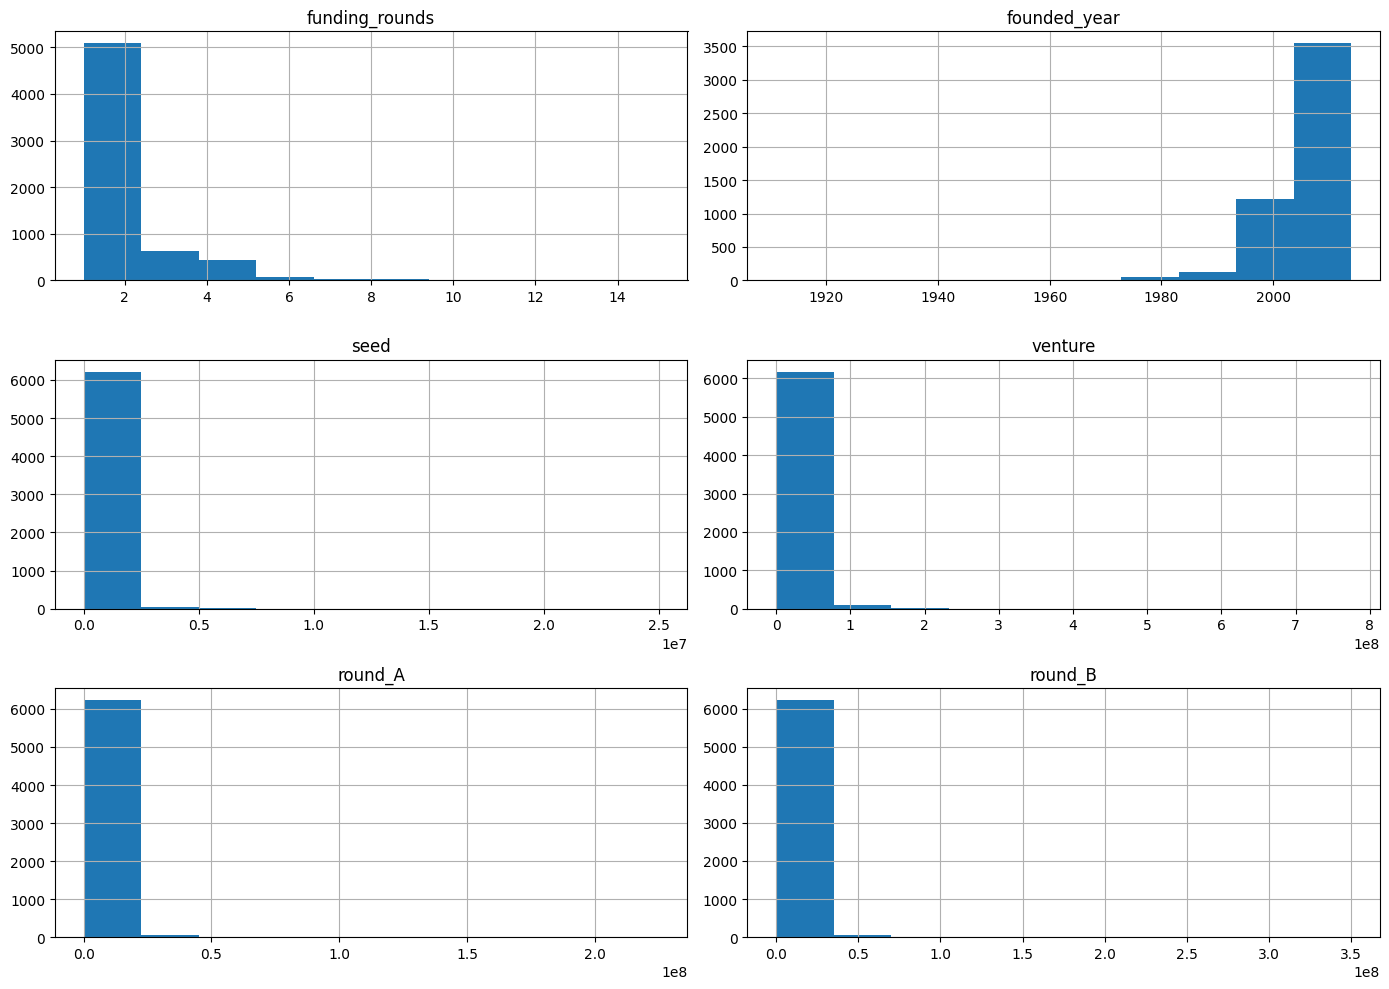

In [16]:
important_numeric = [
    'funding_rounds',
    'founded_year',
    'seed',
    'venture',
    'round_A',
    'round_B'
]

df[important_numeric].hist(figsize=(14,10))
plt.tight_layout()
plt.show()

Most funding-related features are heavily right-skewed, with a small number of companies receiving exceptionally large investments compared to the majority of startups.


## Step 6: Categorical & Object Feature Analysis

Object-type features in the dataset serve different purposes.
Some contain meaningful business information, while others behave primarily as identifiers or raw metadata.

In [17]:
# Clean column names by stripping whitespace
df.columns = df.columns.str.strip()

**1. Identifier-like Features:**

The following features behave primarily as identifiers and are unlikely to provide useful predictive information.

In [18]:
df[['permalink', 'name', 'homepage_url']].head()

,permalink,name,homepage_url
0,/organization/waywire,#waywire,http://www.waywire.com
6,/organization/fox-networks,.Fox Networks,http://www.dotfox.com
18,/organization/1000-markets,1000 Markets,http://www.1000markets.com
20,/organization/1000memories,1000memories,http://1000memories.com
27,/organization/100plus,100Plus,http://www.100plus.com


These features contain mostly unique values per company and may introduce noise or overfitting during model training.

**2. Geographic Features:**

In [19]:
country_code_counts = df['country_code'].value_counts().head(10)
print(country_code_counts)

country_code
USA    4248
GBR     297
CAN     169
DEU     118
ISR     107
FRA      94
CHN      61
ESP      58
IND      50
IRL      34
Name: count, dtype: int64


In [20]:
state_code_counts = df['state_code'].value_counts().head(10)
print(state_code_counts)

state_code
CA    1962
NY     428
MA     338
TX     192
WA     172
IL     110
CO     104
PA      96
ON      83
FL      78
Name: count, dtype: int64


In [21]:
df['region'].value_counts().head(10)

,count
region,
SF Bay Area,1494
New York City,395
Boston,323
Los Angeles,228
London,175
Seattle,170
"Washington, D.C.",106
Chicago,104
San Diego,102


In [22]:
df['city'].value_counts().head(10)

,count
city,
San Francisco,520
New York,363
Palo Alto,141
London,131
Mountain View,120
Seattle,113
Sunnyvale,105
Austin,97
Santa Clara,89


`country_code` and `region` appear potentially informative, as they capture meaningful geographic startup ecosystems such as the SF Bay Area, New York City, and London.

In contrast, `state_code` and especially `city` introduce increasingly sparse and high-cardinality information.

**3. Business Domain Features:**

In [23]:
market_counts = df['market'].value_counts().head(15)
print(market_counts)

market
Software                718
Curated Web             459
Mobile                  342
Biotechnology           322
Enterprise Software     249
Games                   227
Advertising             214
E-Commerce              188
Social Media            162
Clean Technology        138
Hardware + Software     137
Semiconductors          127
Health Care             118
Web Hosting             115
Security                115
Name: count, dtype: int64


In [24]:
category_list_counts = df['category_list'].value_counts().head(10)
print(category_list_counts)

category_list
|Software|               580
|Curated Web|            312
|Biotechnology|          308
|Mobile|                 196
|Enterprise Software|    181
|Games|                  148
|Advertising|            135
|Clean Technology|       127
|Hardware + Software|    124
|Semiconductors|         122
Name: count, dtype: int64


`market` provides a relatively clean representation of startup domains, whereas `category_list` contains highly complex multi-category values. This may require advanced preprocessing such as multi-label encoding or feature extraction.

**4. Date Features:**

In [25]:
date_cols = [
    'founded_at',
    'founded_month',
    'founded_quarter',
    'first_funding_at',
    'last_funding_at'
]

df[date_cols].head()

,founded_at,founded_month,founded_quarter,first_funding_at,last_funding_at
0,2012-06-01,2012-06,2012-Q2,2012-06-30,2012-06-30
6,NaN,NaN,NaN,2007-01-16,2007-01-16
18,2009-01-01,2009-01,2009-Q1,2009-05-15,2009-05-15
20,2010-07-01,2010-07,2010-Q3,2010-01-01,2011-02-16
27,2011-09-16,2011-09,2011-Q3,2011-11-02,2011-11-30


Date-related features will later require transformation into structured numerical representations before modeling.

**5. funding_total_usd:**

In [26]:
df['funding_total_usd'].head()

,funding_total_usd
0,"17,50,000"
6,"49,12,393"
18,"5,00,000"
20,"25,35,000"
27,"12,50,000"


Although stored as an object feature, `funding_total_usd` represents numerical data and will later be converted into numeric format.

## Step 7: Numeric Feature Cleaning & Transformation

After the exploratory analysis, we apply numeric preprocessing steps to prepare the data for machine learning.

This stage includes:
- converting numeric-like object columns into numeric format,
- handling missing numeric values,
- transforming highly skewed funding-related variables,
- and identifying extremely sparse features.

### Convert Object to Numeric

Missing `founded_year` values will be imputed using the median to preserve the overall distribution while remaining robust to outliers.

The `funding_total_usd` feature, stored as an object due to formatting, will be cleaned and converted into numeric format for analysis and model training.

In [27]:
median_year = df['founded_year'].median()

df['founded_year'] = df['founded_year'].fillna(median_year)

print(f"Null: {df['founded_year'].isnull().sum()}")
print(f"median founded_year: {median_year:.0f}")

Null: 0
median founded_year: 2007


In [28]:
df['funding_total_usd'].head(3)

,funding_total_usd
0,"17,50,000"
6,"49,12,393"
18,"5,00,000"


In [29]:
# Clean and convert funding_total_usd
df['funding_total_usd'] = (
    df['funding_total_usd']
    .str.strip()
    .replace('-', np.nan)
    .str.replace(',', '', regex=False)
    .astype(float)
)

# Verify conversion
print(f"current type: {df['funding_total_usd'].dtype}")
print(f"missing values: {df['funding_total_usd'].isnull().sum()}")

df['funding_total_usd'].head()

current type: float64
missing values: 919


,funding_total_usd
0,1750000.0
6,4912393.0
18,500000.0
20,2535000.0
27,1250000.0


After cleaning the formatting and placeholder symbols, the `funding_total_usd` feature was successfully converted into a numeric format.

The conversion process also revealed 919 missing values that were previously stored as placeholder strings (`-`).

In [30]:
# Handle missing values in funding_total_usd
median_funding = df['funding_total_usd'].median()

df['funding_total_usd'] = df['funding_total_usd'].fillna(median_funding)
print(f"missing values: {df['funding_total_usd'].isnull().sum()}")
print(f"median funding_total_usd: {median_funding:,.0f}")

missing values: 0
median funding_total_usd: 4,500,000


The funding-related features exhibit highly skewed distributions with extreme outliers, as observed during the exploratory analysis.
Therefore, median imputation was preferred over mean imputation, since the median is more robust to extreme values.

### Apply Log Transformation

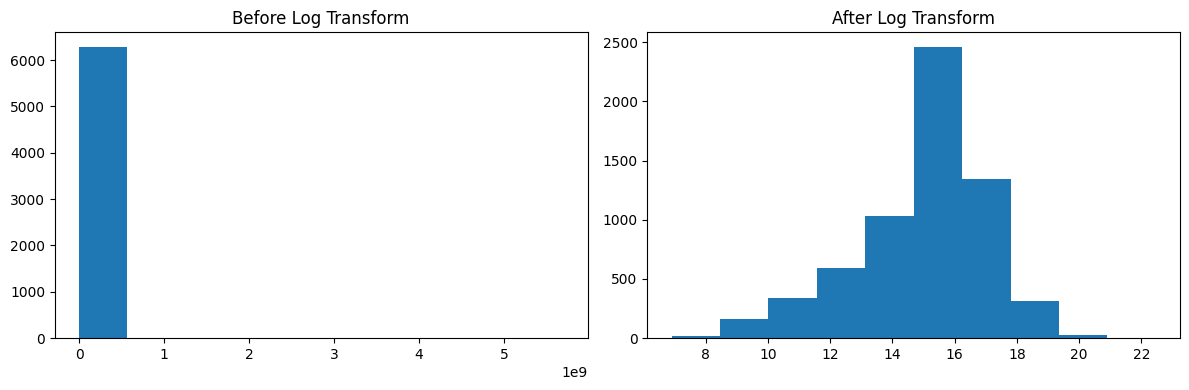

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['funding_total_usd'])
axes[0].set_title('Before Log Transform')

axes[1].hist(np.log1p(df['funding_total_usd']))
axes[1].set_title('After Log Transform')

plt.tight_layout()
plt.show()

In [32]:
log_features = [
    'funding_total_usd',
    'seed',
    'venture',
    'angel',
    'debt_financing',
    'round_A',
    'round_B',
    'round_C',
    'round_D'
]

for col in log_features:
    df[col] = np.log1p(df[col])

In [33]:
# Verify transformation
df[log_features].describe()

,funding_total_usd,seed,venture,angel,debt_financing,round_A,round_B,round_C,round_D
count,6295.000000,6295.000000,6295.000000,6295.000000,6295.000000,6295.000000,6295.000000,6295.000000,6295.000000
mean,14.990123,2.683669,9.364226,0.937347,1.281920,4.034301,3.055683,1.775105,0.804690
std,2.064592,5.170753,7.824813,3.388438,4.155557,6.730439,6.302703,5.088816,3.547999
min,6.908755,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,13.910822,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,15.319588,0.000000,14.225898,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,16.347618,0.000000,16.213406,0.000000,0.000000,13.815512,0.000000,0.000000,0.000000
max,22.463732,17.034386,20.468374,17.216708,20.905587,19.231611,19.673444,19.113828,19.336971


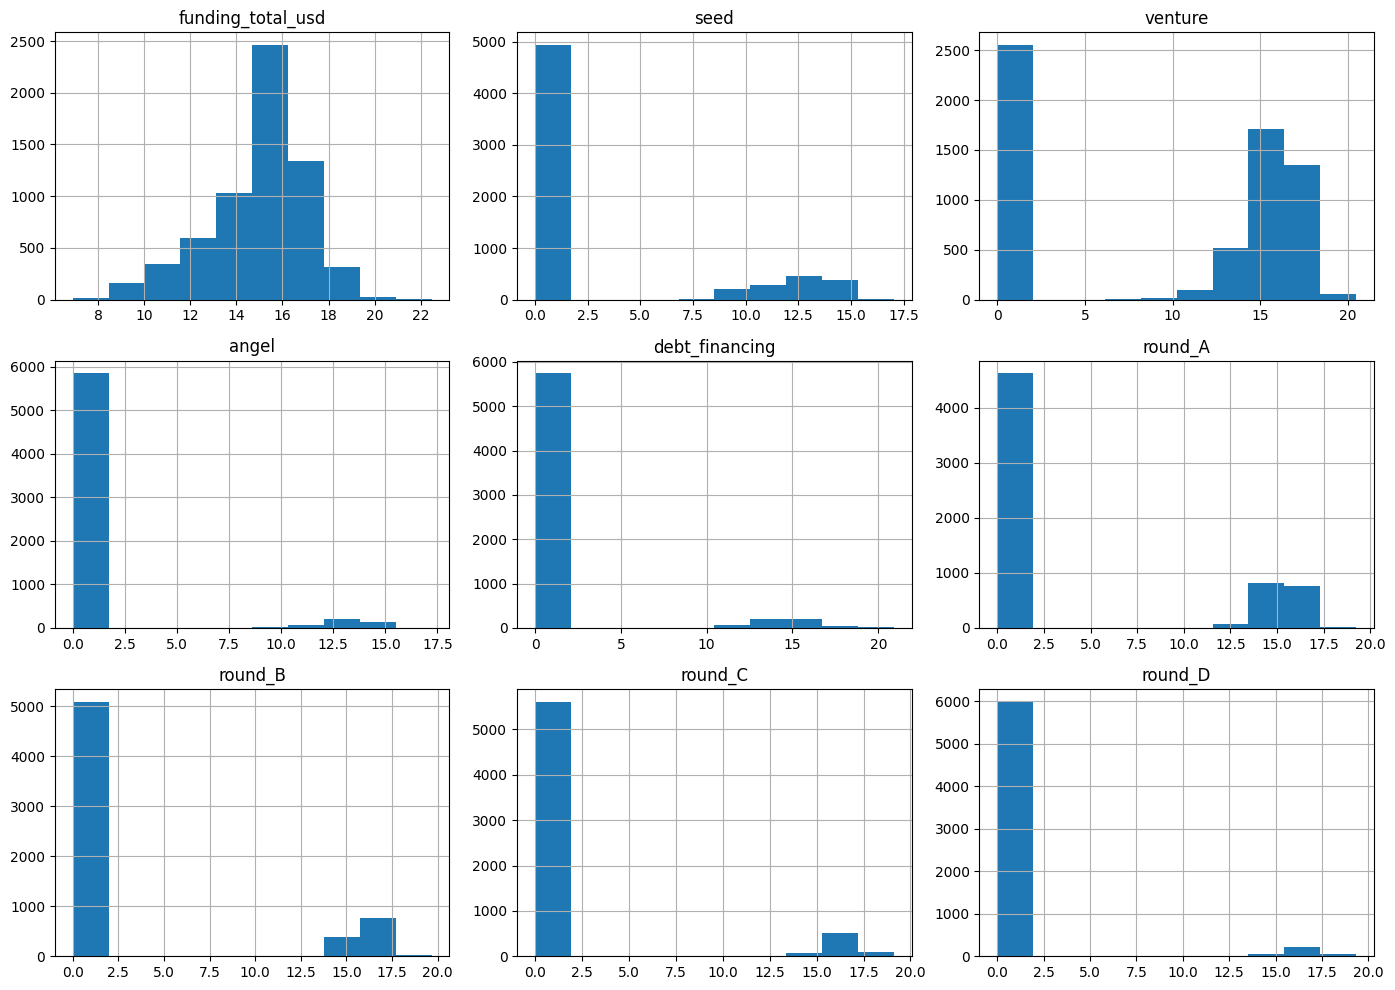

In [34]:
df[log_features].hist(figsize=(14,10))
plt.tight_layout()
plt.show()

Log transformation reduced extreme skewness and compressed large outliers into a more learnable numerical scale.

### Sparse Feature Analysis and Removal

Several funding-related features contain mostly zero values and provide very limited variability.

To reduce noise and unnecessary dimensionality, highly sparse features will be identified and evaluated for removal.

In [35]:
# Display features with the highest percentage of zero values
zero_analysis.head(15)

,Zero %
round_H,100.000000
post_ipo_debt,99.968229
secondary_market,99.952343
product_crowdfunding,99.952343
equity_crowdfunding,99.936458
round_G,99.936458
post_ipo_equity,99.857029
round_F,99.491660
convertible_note,99.428118
undisclosed,98.919778


In [36]:
SPARSE_THRESHOLD = 99

sparse_cols = zero_analysis[
    zero_analysis['Zero %'] >= SPARSE_THRESHOLD
].index.tolist()

print("Sparse columns:")
print(sparse_cols)

Sparse columns:
['round_H', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding', 'equity_crowdfunding', 'round_G', 'post_ipo_equity', 'round_F', 'convertible_note']


In [37]:
sparse_cols_to_drop = [
    'round_H',
    'round_G',
    'post_ipo_debt',
    'product_crowdfunding',
    'secondary_market'
]

df = df.drop(columns=sparse_cols_to_drop)

print("Columns removed:", len(sparse_cols_to_drop))
print("Remaining columns:", len(df.columns))

Columns removed: 5
Remaining columns: 35


Several extremely sparse funding-stage features were removed because more than 99% of their values were equal to zero.

Such features provide very limited variability and are unlikely to contribute meaningful predictive power while increasing dataset dimensionality.

The remaining sparse features will be further inspected before final feature selection.

In [38]:
remaining_sparse_features = [
    'equity_crowdfunding',
    'undisclosed',
    'convertible_note',
    'private_equity',
    'post_ipo_equity'
]

df[remaining_sparse_features].describe().T

,count,mean,std,min,25%,50%,75%,max
equity_crowdfunding,6295.0,1.411129e+03,7.653789e+04,0.0,0.0,0.0,0.0,5.500000e+06
undisclosed,6295.0,1.069192e+05,2.063324e+06,0.0,0.0,0.0,0.0,1.250000e+08
convertible_note,6295.0,7.953678e+03,2.021176e+05,0.0,0.0,0.0,0.0,1.352014e+07
private_equity,6295.0,1.777664e+06,2.160615e+07,0.0,0.0,0.0,0.0,7.710000e+08
post_ipo_equity,6295.0,1.070626e+06,6.085177e+07,0.0,0.0,0.0,0.0,4.700000e+09


In [39]:
for col in remaining_sparse_features:
    zero_pct = (df[col] == 0).mean() * 100
    unique_vals = df[col].nunique()

    print(f"{col:<25} zeros: {zero_pct:.1f}% | unique: {unique_vals}")

equity_crowdfunding       zeros: 99.9% | unique: 5
undisclosed               zeros: 98.9% | unique: 65
convertible_note          zeros: 99.4% | unique: 33
private_equity            zeros: 98.0% | unique: 113
post_ipo_equity           zeros: 99.9% | unique: 10


These features exhibit extremely sparse distributions and very limited variability.

In [40]:
corr_with_target = (
    df[remaining_sparse_features]
    .corrwith(df['success'])
    .sort_values(ascending=False)
)

print(corr_with_target)

private_equity         0.047418
undisclosed            0.028323
equity_crowdfunding    0.015482
post_ipo_equity        0.010588
convertible_note      -0.009018
dtype: float64


To better evaluate feature usefulness, correlation analysis with the target variable was performed.

In [41]:
final_sparse_drop = [
    'equity_crowdfunding',
    'undisclosed',
    'convertible_note',
    'private_equity',
    'post_ipo_equity'
]

df = df.drop(columns=final_sparse_drop)
print("droped columns:", len(final_sparse_drop))
print("Remaining columns:", len(df.columns))

droped columns: 5
Remaining columns: 30


Due to their extreme sparsity and weak correlation with the target variable, these features were removed from the final modeling dataset.

## Step 8: Cleaning Object Features

In [42]:
redundant_object_features = [
    'permalink',
    'name',
    'homepage_url',
    'status',
    'state_code',
    'city',
    'region',
    'founded_at',
    'founded_month',
    'founded_quarter',
    'first_funding_at',
    'last_funding_at'
]

df = df.drop(columns=redundant_object_features)
print("Droped columns:", len(redundant_object_features))
print("Final feature count:", len(df.columns))

Droped columns: 12
Final feature count: 18


Most redundant object-based features were removed.

In [43]:
df['category_list'].value_counts()

,count
category_list,
|Software|,580
|Curated Web|,312
|Biotechnology|,308
|Mobile|,196
|Enterprise Software|,181
...,...
|Internet|Privacy|,1
|Collaborative Consumption|E-Commerce|Tourism|Marketplaces|Travel|,1
|Facebook Applications|E-Commerce|,1


In [44]:
df = df.drop(columns=['category_list'])

The `category_list` feature contains multi-label textual category combinations with very high cardinality.

Since the cleaner `market` feature already provides a normalized business-domain representation, `category_list` was removed to reduce preprocessing complexity and avoid sparse high-dimensional encoding.

In [45]:
df['market'] = df['market'].fillna('Unknown')
df['country_code'] = df['country_code'].fillna('Unknown')
print('Null Values:')
print(df[['market', 'country_code']].isnull().sum())
print("Remaining columns:", len(df.columns))

Null Values:
market          0
country_code    0
dtype: int64
Remaining columns: 17


Missing values in `market` and `country_code` were imputed with the 'Unknown' category.

Later, will be encoding for this features.

## Step 9 — Final Correlation Overview & Export


The heatmap below presents Pearson correlations between the numerical features in the dataset.

Only numerical variables were included, since Pearson correlation is designed to measure linear relationships between continuous numeric features.

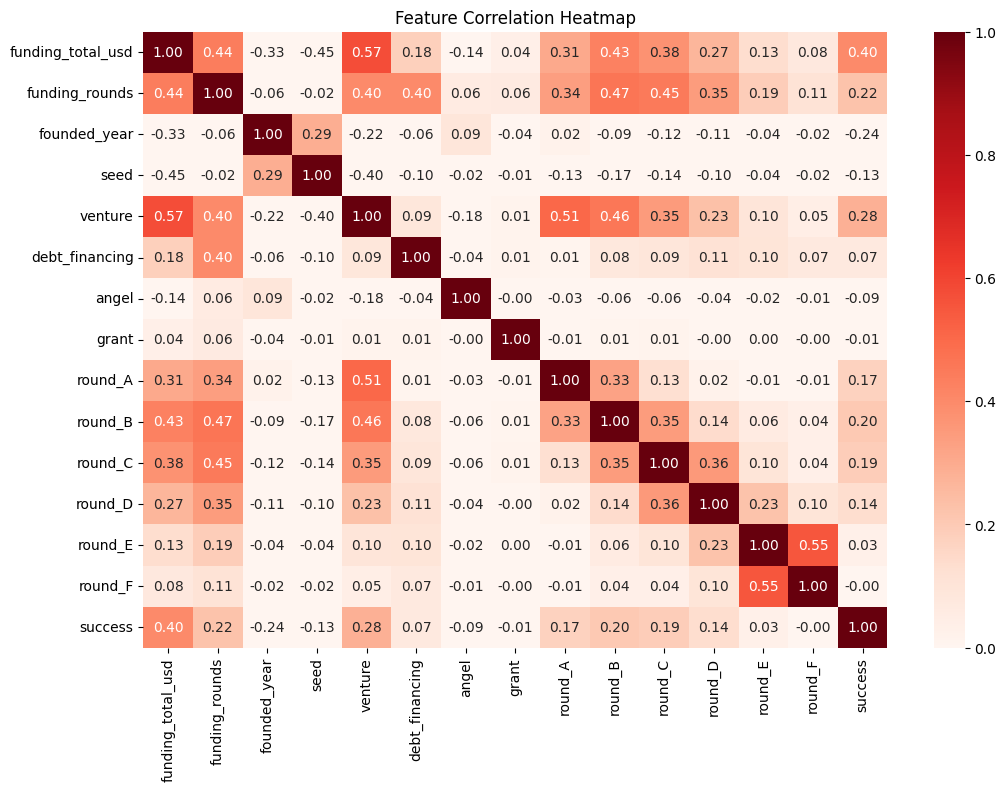

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric features for correlation analysis
corr_matrix = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap=plt.cm.Reds,
    vmin=0,
    vmax=1,
    fmt=".2f"
)

plt.title('Feature Correlation Heatmap')
plt.show()

The correlation analysis suggests that startup success is influenced by multiple moderately correlated funding-related features rather than a single dominant predictor.

This pattern indicates a complex and potentially non-linear relationship structure within the dataset.

In [47]:
df.to_csv('cleaned_crunchbase.csv', index=False)

print("Dataset exported successfully.")
print("Final dataset shape:", df.shape)

Dataset exported successfully.
Final dataset shape: (6295, 17)


The preprocessing pipeline produced a cleaned and modeling-ready dataset containing numerical funding features and selected categorical variables.

The dataset is now ready for encoding, train-test splitting, and machine learning model development in the next notebook.